# Práctica 7 sobre de extremos de funcións de varias variables
En esta práctica pretendemos hallar los mínimos de funcies escalares de variables reales. Es decir, dado $n>1$ y $f:\mathbf{x}\in\mathbb{R}^n\to\mathbb{R}$, pretendemos resolver:

Hallar $\mathbf{u}\in\mathbb{R}^n$ tal que $\displaystyle f(\mathbf{u}) = \min_{\mathbf{x}\in\mathbb{R}^n}f(\mathbf{x}).$

Tomaremos como ejemplo en esta práctica la función

$f(x,y) = (x-1)^2 + (y-x^3)^2,$

que presenta un mínimo en $(1,1)$.

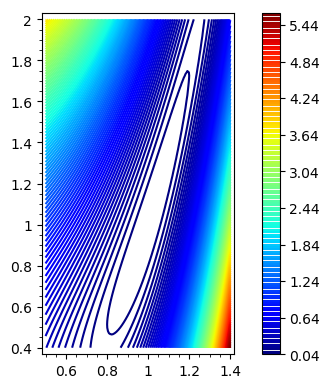

In [243]:
f = lambda x,y: (x-1)^2 + (y-x^3)^2
var('x y')
opts = {'fill':False, 'cmap':'jet', 'contours':150, 'colorbar':True}
contour_plot(f, (x,0.5,1.4), (y,0.4,2), **opts)

## Cálculo con `minimize`

El comando `minimize` permite aproximar un mínimo local de una función escalar de varias variables partiendo de un iterante inicial dado. Este comando es unha interfaz para una serie de algoritmos numéricos. 

Observa que la variable sobre la que trabaja minimize debe ser vectorial.

In [244]:
minimize(lambda u: f(*u), [.1,.3])

(1.000007477391949, 1.0000205135474194)

## Ecuación de Euler
Utilizando la condición necesaria de mínimo, se pueden calcular los mínimos locales resolviendo las ecuaciones de Euler, es decir, $\nabla f(u) = 0$. Recuperamos la función `raices` de la práctica anterior para observar las ráices de $\nabla f$.

In [245]:
def raices(f, x0=-5, x1=5, y0=-5, y1=5):
    var('x y')
    opts = {'fill':False, 'contours':[0]}
    g1 = contour_plot(f(x,y)[0], (x, x0, x1), (y, y0, y1), cmap=['blue'],  **opts)
    g2 = contour_plot(f(x,y)[1], (x, x0, x1), (y, y0, y1), cmap=['green'], **opts)
    return g1+g2

Antes definir el gradiente simbólico $df$, convirtiendo a vector su matriz jacobiana.

In [246]:
df = lambda a,b: vector(jacobian(f(x,y), [x,y]))(x=a, y=b)
df(x,y)

(6*(x^3 - y)*x^2 + 2*x - 2, -2*x^3 + 2*y)

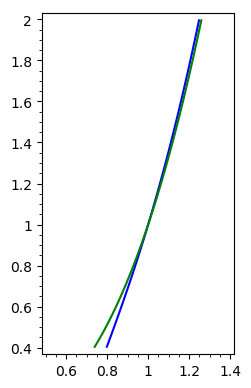

In [247]:
raices(df, 0.5,1.4, 0.4,2)

Ahora podemos usar `newton` para encontrar la raíz de `df`.

In [248]:
def newton(f, df, x0, xtol=1e-12, rtol=1e-14, M=100):
    """NEWTON    Calculo de raices por Newton multidimensional."""
    v = [vector(RDF,x0)]
    for k in range(M):
        dfx = matrix(RDF,df(*v[k]))
        if rank(dfx) < len(x0):
            raise RuntimeError('La matriz jacobiana es singular en un iterante.')
        r = v[k] - dfx.solve_right(vector(RDF,f(*v[k])));
        v.append(r)
        # test de parada
        if norm(r - v[k]) < xtol or norm(vector(RDF,f(*r))) < rtol:
            return r, len(v), v
    raise RuntimeError('Excedido el número máximo de iteraciones.')

Como hicimos en la práctica anterior, calculamos simbólicamente la jacobiana de $\nabla f$, es decir, la hessiana de $f$.

In [249]:
var('x y')
Hf = lambda a,b: jacobian(df(x,y), [x,y])(x=a, y=b)
newton(df, Hf, [1.1,1.2])

((1.0000000000000013, 1.0000000000000038),
 6,
 [(1.1, 1.2),
  (1.0463691944653009, 1.1363201759090424),
  (1.002567741283938, 1.001784467540202),
  (1.000088563209234, 1.000247242078267),
  (1.0000000098149304, 1.0000000059182916),
  (1.0000000000000013, 1.0000000000000038)])

## El método del gradiente

El método del gradiente o de máximo descenso consiste en construir una sucesión que idealmente converjerá al mínimo, $\{\mathbf{x}_n\}_{n\geq 0},\ \mathbf{x}_n\in\mathbb{R}^n$, del siguiente modo:


$\left\{\begin{array}{l} 
\mathbf{x}_0 \text{ dado},\\ 
\mathbf{x}_{n+1} = \mathbf{x}_n -\rho \nabla f (\mathbf{x}_n),\ n\geq 0, \end{array}
\right.$

siendo $\rho>0$ un número real dado. El método converge cuando dos iterantes consecutivos están cerca o cuando el gradiente de $J$ es muy pequeño. Debe parar incondicionalmente cuando se supera el número máximo de iteraciones.

En el método de gradiente, debemos usar `vector(RDF, x0)`, en vez de la lista `x0`, para garantizar que el siguiente iterante está bien definido. Además, usaremos `norm` para calcular la longitud de un vector.

In [250]:
rho = 1
v  = vector(RDF, [0,0])
v - rho*df(*v) # CORRECTO, [0,0] - rho*df(*v) daría ERROR

(2, 0.0)

**Ejercicio 1:**
1. Tomando de ejemplo la función `newton` de la práctica anterior, programa el método del gradiente.
2. Comprueba si el método encuentra el mínimo de $f(x,y) = (x-1)^2 + (y-x^3)^2$ partiendo de $(1.1, 1.2)$. 
3. Usa la función `ruta` de la práctica anterior, aplicada a `df`, para ver el camino seguido por los iterantes.
4. Intenta converger con `xtol=1e-5`, `rtol=1e-7`: para ello, o bien debes partir de un iterante más cercano a $(1.1)$, o bien debes admitir más iteraciones. 


In [251]:
def gradiente(f, df, x0, rho=1e-2, xtol=1e-4, rtol=1e-6, M=1000):
    v = [vector(RDF,x0)]
    for k in range(M):
        r = v[k] - rho*df(*v[k])
        v.append(r)
        if norm(r-v[k]) < xtol or norm(df(*r)) < rtol:
            return r, k+1, v
        x0 = r
    raise RuntimeError('Excedido el número máximo de iteraciones.') 

In [252]:
r,k,v = gradiente(f, df, [1.1, 1.2])
r,k

((1.0162337359320741, 1.0542796801231653), 802)

In [253]:
def raices(f, x0=-5, x1=5, y0=-5, y1=5):
    var('x y')
    opts = {'fill':False, 'contours':[0]}
    g1 = contour_plot(f(x,y)[0], (x, x0, x1), (y, y0, y1), cmap=['blue'],  **opts)
    g2 = contour_plot(f(x,y)[1], (x, x0, x1), (y, y0, y1), cmap=['green'], **opts)
    return g1+g2

In [254]:
def ruta(f, v, x0=-5, x1=5, y0=-5, y1=5):
    g1 = raices(f, x0, x1, y0, y1)
    g2 = line(v, marker='o', color='red')
    return g1+g2

(1.0162337359320741, 1.0542796801231653) 802


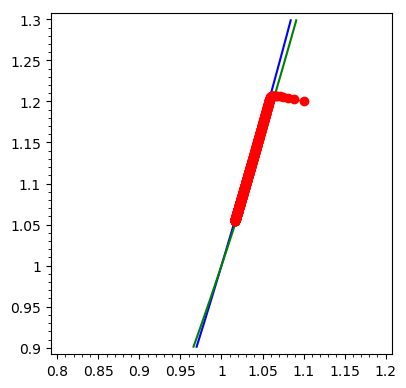

In [255]:
r,k,v = gradiente(f, df, [1.1, 1.2])
print(r,k)
ruta(df, v, 0.8,1.2, 0.9,1.3)

(1.001579307045328, 1.005222318039856) 767 2.721654208684351e-06


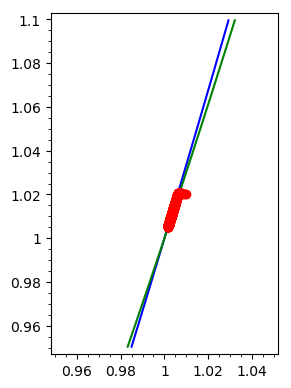

In [256]:
r,k,v = gradiente(f, df, [1.01, 1.02], xtol=1e-5, rtol=1e-7)
print(r,k, f(*r))
ruta(df, v, 0.95,1.05, 0.95,1.1)

**Ejercicio 2:**
1. Usa los comandos anteriores para encontrar el mínimo de la función $g(x) = -x^4+y^3-33x-11y+5$.

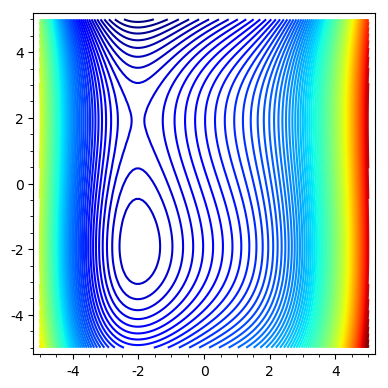

In [257]:
g = lambda x,y: x^4-y^3+33*x+11*y-5
contour_plot(g, (x,-5,5), (y,-5,5), fill=False, cmap='jet', contours=100)

In [258]:
minimize(lambda u: g(*u), [-2,-2])

(-2.0206265750925003, -1.9148948171184201)

In [259]:
dg = lambda a,b: vector(jacobian(g(x,y), [x,y]))(x=a, y=b)
Hg = lambda a,b: jacobian(dg(x,y), [x,y])(x=a, y=b)
r,k,v = newton(dg, Hg, [1,-1])
r,k

((-2.020620010311095, -1.9148542155126764), 6)

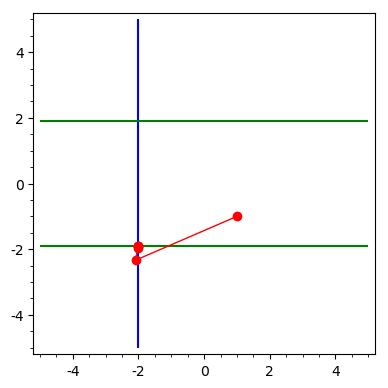

In [260]:
ruta(dg, v)

In [261]:
r,k,v = gradiente(g, dg, [1, -1])
r,k

((-2.0206200103110947, -1.9141266674089776), 61)

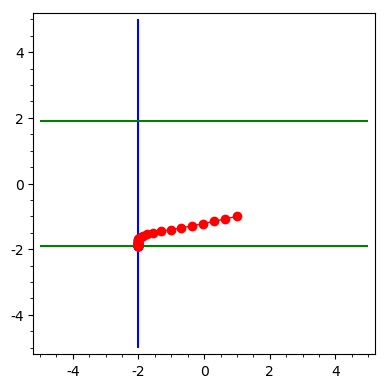

In [262]:
ruta(dg, v)